# Week 1 Lab: Finance Fundamentals with Python

**BUS 696: Generative AI in Finance**  
**Professor Jonathan Hersh**

---

## Learning Objectives

By the end of this lab, you will be able to:
1. Download and explore real stock market data using `yfinance`
2. Understand OHLCV data (Open, High, Low, Close, Volume)
3. Build candlestick charts to visualize price action
4. Calculate daily returns and interpret summary statistics
5. Compute and plot moving averages as trading signals
6. Calculate the Sharpe Ratio to evaluate risk-adjusted performance
7. Compare multiple stocks side by side
8. Write effective prompts for financial analysis tasks

---

## Part 1: Setting Up and Getting Data

In [ ]:
# Install required packages (run once, then you can comment this out)
# !pip install yfinance pandas matplotlib plotly

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import numpy as np

# Make matplotlib plots look nicer
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries loaded!")

All libraries loaded!


### Downloading Stock Data

We use the **yfinance** library to download free stock data from Yahoo Finance.

Let's start by downloading one year of Apple (AAPL) data.

In [3]:
# Download Apple stock data for the past year
apple = yf.download('AAPL', period='1y')

# yfinance returns a MultiIndex when downloading even a single ticker.
# We flatten the columns so they're just 'Open', 'High', 'Low', 'Close', 'Volume'
apple.columns = apple.columns.get_level_values(0)

# Look at the first few rows
apple.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2025-02-12,235.842087,235.931708,229.678946,230.196694,45243300
2025-02-13,240.481873,241.288355,234.547745,235.881926,53614100
2025-02-14,243.538559,244.484433,239.944224,240.203090,40896200
2025-02-18,243.409119,244.116029,240.790527,243.090500,48822500
2025-02-19,243.807388,244.942441,242.104817,243.598308,32204200


### Understanding OHLCV Data

Each row is one trading day. The columns are:

| Column | Meaning |
|--------|---------|
| **Open** | Price when the market opened (9:30 AM ET) |
| **High** | Highest price during the day |
| **Low** | Lowest price during the day |
| **Close** | Price when the market closed (4:00 PM ET) -- this is "the" stock price |
| **Volume** | Number of shares traded that day |

Together these are called **OHLCV** data -- the fundamental building block of financial analysis.

In [4]:
# How much data do we have?
print(f"Date range: {apple.index[0].date()} to {apple.index[-1].date()}")
print(f"Number of trading days: {len(apple)}")
print(f"\nLatest closing price: ${apple['Close'].iloc[-1]:.2f}")

Date range: 2025-02-12 to 2026-02-11
Number of trading days: 251

Latest closing price: $275.50


---

## Part 2: Visualizing Price Data

### Simple Price Chart

Let's start with the most basic chart -- the closing price over time.

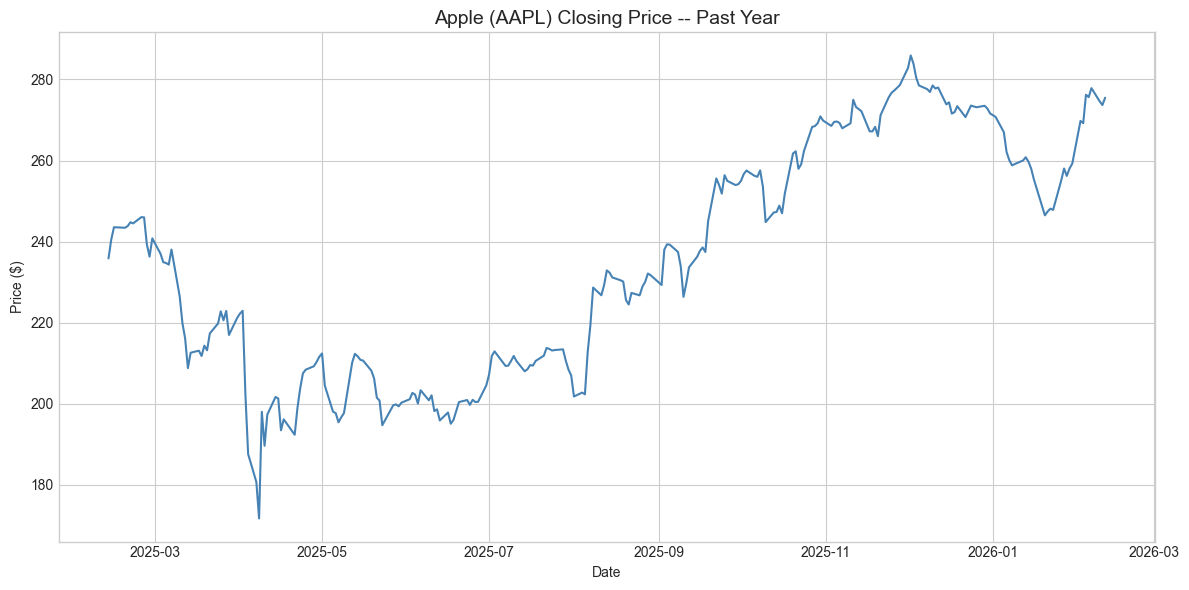

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(apple.index, apple['Close'], color='steelblue', linewidth=1.5)
plt.title('Apple (AAPL) Closing Price -- Past Year', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

### Candlestick Charts

A **candlestick chart** shows all four prices (Open, High, Low, Close) for each day:

- **Green candle**: Close > Open (price went **up** that day)
- **Red candle**: Close < Open (price went **down** that day)
- The **body** shows the range between Open and Close
- The **wicks** (thin lines) show the High and Low

Traders use candlestick charts because they pack much more information than a simple line chart.

We'll use **Plotly** to make an interactive candlestick chart.

In [6]:
# Interactive candlestick chart -- last 3 months of data
recent = apple.last('3M')

fig = go.Figure(data=[go.Candlestick(
    x=recent.index,
    open=recent['Open'],
    high=recent['High'],
    low=recent['Low'],
    close=recent['Close'],
    name='AAPL'
)])

fig.update_layout(
    title='Apple (AAPL) Candlestick Chart -- Last 3 Months',
    yaxis_title='Price ($)',
    xaxis_title='Date',
    xaxis_rangeslider_visible=True,
    template='plotly_white',
    height=500
)

fig.show()

AttributeError: 'DataFrame' object has no attribute 'last'

**Try it:** Hover over candles to see the exact OHLC values. Use the range slider at the bottom to zoom into specific date ranges.

---

### Volume Chart

**Volume** tells you how many shares were traded. High volume often accompanies big price moves (earnings announcements, news events, etc.).

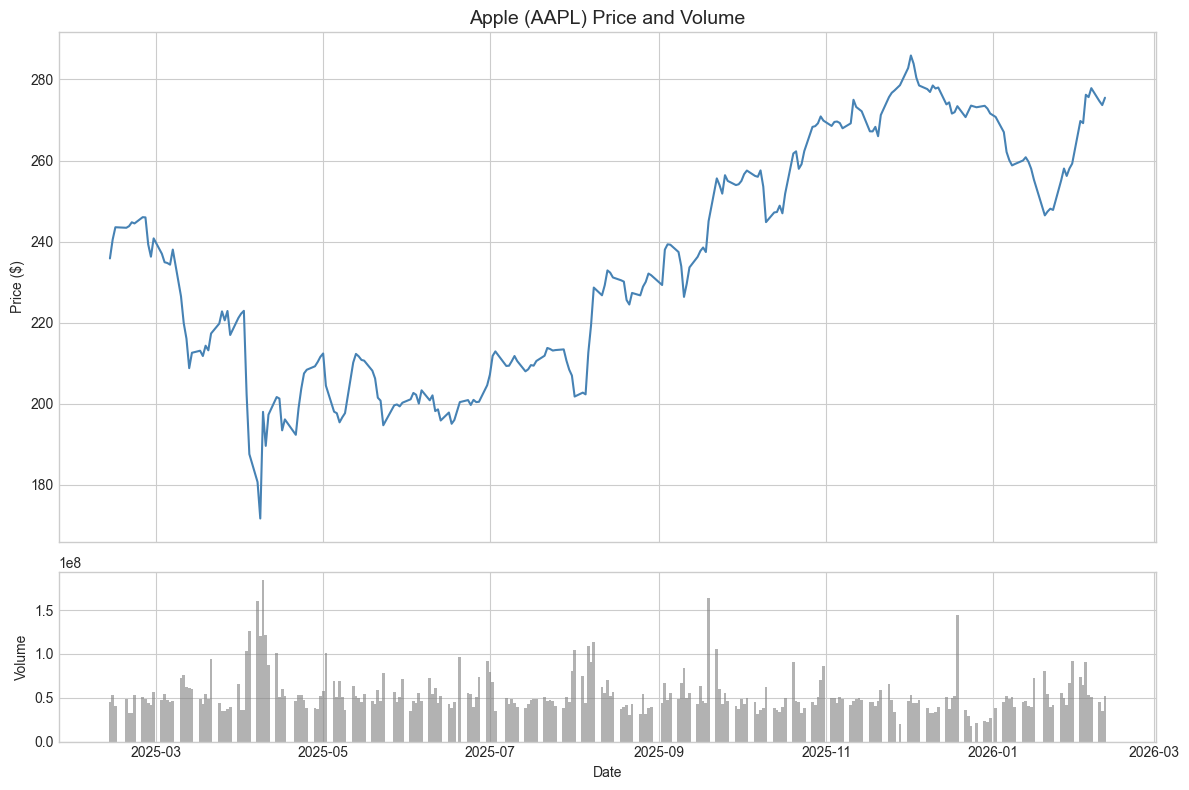

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), 
                                gridspec_kw={'height_ratios': [3, 1]}, 
                                sharex=True)

# Price chart on top
ax1.plot(apple.index, apple['Close'], color='steelblue', linewidth=1.5)
ax1.set_ylabel('Price ($)')
ax1.set_title('Apple (AAPL) Price and Volume', fontsize=14)

# Volume chart on bottom
ax2.bar(apple.index, apple['Volume'], color='gray', alpha=0.6, width=1)
ax2.set_ylabel('Volume')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.show()

---

## Part 3: Returns -- Measuring Gains and Losses

The **return** on a stock tells you how much it gained or lost as a percentage:

$$\text{Return}_t = \frac{\text{Price}_t - \text{Price}_{t-1}}{\text{Price}_{t-1}}$$

In pandas, `pct_change()` does this calculation automatically.

In [8]:
# Calculate daily returns
apple['Return'] = apple['Close'].pct_change()

# Show the last 10 days of prices and returns
apple[['Close', 'Return']].tail(10)

Price,Close,Return
Date,,
2026-01-29,258.038544,0.007175
2026-01-30,259.237427,0.004646
2026-02-02,269.757599,0.040581
2026-02-03,269.228088,-0.001963
2026-02-04,276.231506,0.026013
2026-02-05,275.652069,-0.002098
2026-02-06,277.859985,0.008010
2026-02-09,274.619995,-0.011661
2026-02-10,273.679993,-0.003423


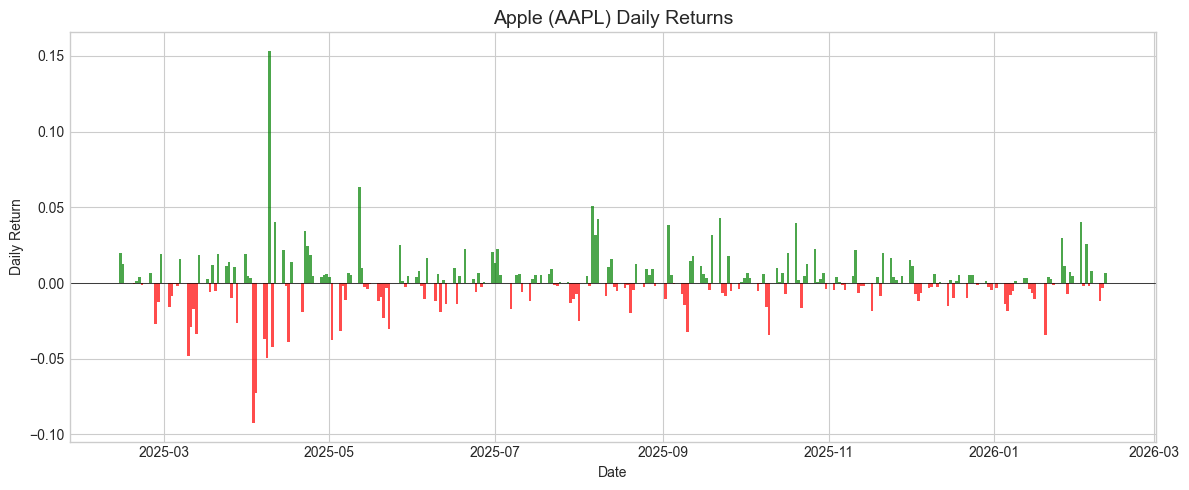

In [9]:
# Plot daily returns
plt.figure(figsize=(12, 5))
plt.bar(apple.index, apple['Return'], color=apple['Return'].apply(
    lambda x: 'green' if x >= 0 else 'red'), alpha=0.7, width=1)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.title('Apple (AAPL) Daily Returns', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.tight_layout()
plt.show()

**What you're seeing:**
- Returns fluctuate around zero -- like a seismograph
- Most days are small moves
- Occasionally there are big spikes (earnings, news, market events)
- This "bounciness" is **volatility** -- a key measure of risk

### Summary Statistics

Let's compute the key numbers that describe Apple's performance.

In [10]:
# Daily statistics
avg_daily_return = apple['Return'].mean()
daily_std = apple['Return'].std()
best_day = apple['Return'].max()
worst_day = apple['Return'].min()
total_return = (apple['Close'].iloc[-1] / apple['Close'].iloc[0]) - 1

# Annualized statistics (252 trading days per year)
annual_return = avg_daily_return * 252
annual_volatility = daily_std * np.sqrt(252)

print("Apple (AAPL) -- Summary Statistics")
print("=" * 50)
print(f"\nDaily:")
print(f"  Average daily return:  {avg_daily_return:.4f} ({avg_daily_return*100:.2f}%)")
print(f"  Daily std deviation:   {daily_std:.4f} ({daily_std*100:.2f}%)")
print(f"  Best day:              {best_day:.4f} ({best_day*100:.2f}%)")
print(f"  Worst day:             {worst_day:.4f} ({worst_day*100:.2f}%)")
print(f"\nAnnualized:")
print(f"  Annualized return:     {annual_return:.4f} ({annual_return*100:.2f}%)")
print(f"  Annualized volatility: {annual_volatility:.4f} ({annual_volatility*100:.2f}%)")
print(f"\nTotal return over period: {total_return*100:.2f}%")
print(f"  $1,000 invested became: ${1000*(1+total_return):,.2f}")

Apple (AAPL) -- Summary Statistics

Daily:
  Average daily return:  0.0008 (0.08%)
  Daily std deviation:   0.0200 (2.00%)
  Best day:              0.1533 (15.33%)
  Worst day:             -0.0925 (-9.25%)

Annualized:
  Annualized return:     0.2064 (20.64%)
  Annualized volatility: 0.3180 (31.80%)

Total return over period: 16.82%
  $1,000 invested became: $1,168.15


### Return Distribution

A histogram shows how returns are distributed. Most days cluster near zero, with "fat tails" of extreme moves.

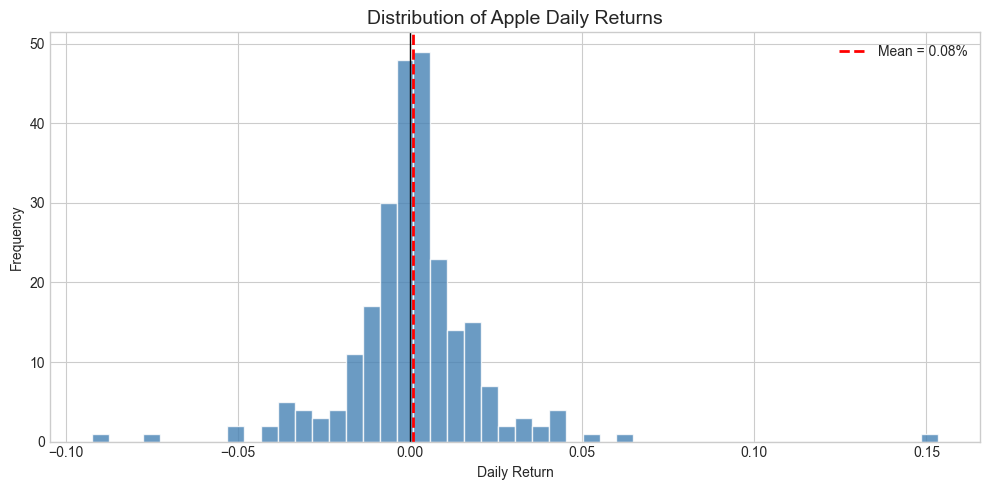

In [11]:
plt.figure(figsize=(10, 5))
apple['Return'].dropna().hist(bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(x=0, color='black', linewidth=1)
plt.axvline(x=avg_daily_return, color='red', linewidth=2, linestyle='--', label=f'Mean = {avg_daily_return*100:.2f}%')
plt.title('Distribution of Apple Daily Returns', fontsize=14)
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

---

## Part 4: Moving Averages

A **moving average** smooths out daily noise to reveal the underlying trend.

- **20-day MA**: Average of the last 20 closing prices (short-term trend)
- **50-day MA**: Medium-term trend

Each day, the window "moves" forward -- drop the oldest price, add the newest.

**Trading signals:**
- Price **above** the MA = uptrend (bullish)
- Price **below** the MA = downtrend (bearish)
- Price **crosses** the MA = potential trend reversal

In [12]:
# Calculate moving averages
apple['MA20'] = apple['Close'].rolling(window=20).mean()
apple['MA50'] = apple['Close'].rolling(window=50).mean()

# Show a few rows -- note the first 19/49 rows are NaN (not enough data yet)
apple[['Close', 'MA20', 'MA50']].tail(10)

Price,Close,MA20,MA50
Date,,,
2026-01-29,258.038544,258.027057,268.203835
2026-01-30,259.237427,257.408636,268.044385
2026-02-02,269.757599,257.358684,268.095737
2026-02-03,269.228088,257.469580,268.114120
2026-02-04,276.231506,258.175420,268.318728
2026-02-05,275.652069,258.953693,268.407046
2026-02-06,277.859985,259.906799,268.451004
2026-02-09,274.619995,260.681422,268.409182
2026-02-10,273.679993,261.365086,268.336971


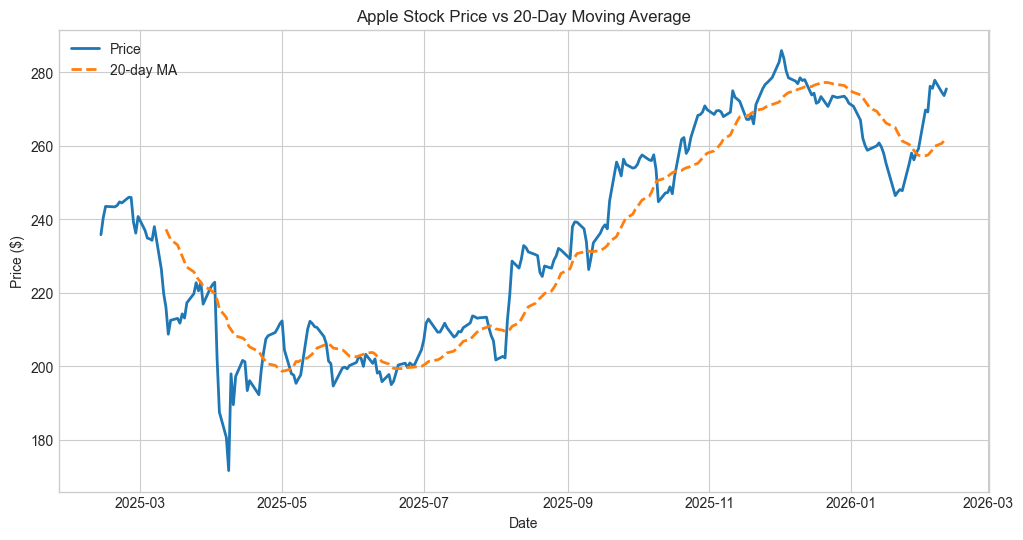

In [13]:
# Calculate 20-day moving average
apple['MA20'] = apple['Close'].rolling(window=20).mean()

# Plot price versus moving average
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(apple['Close'], label='Price', linewidth=2)
plt.plot(apple['MA20'], label='20-day MA', linewidth=2, linestyle='--')
plt.legend()
plt.title('Apple Stock Price vs 20-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.show()


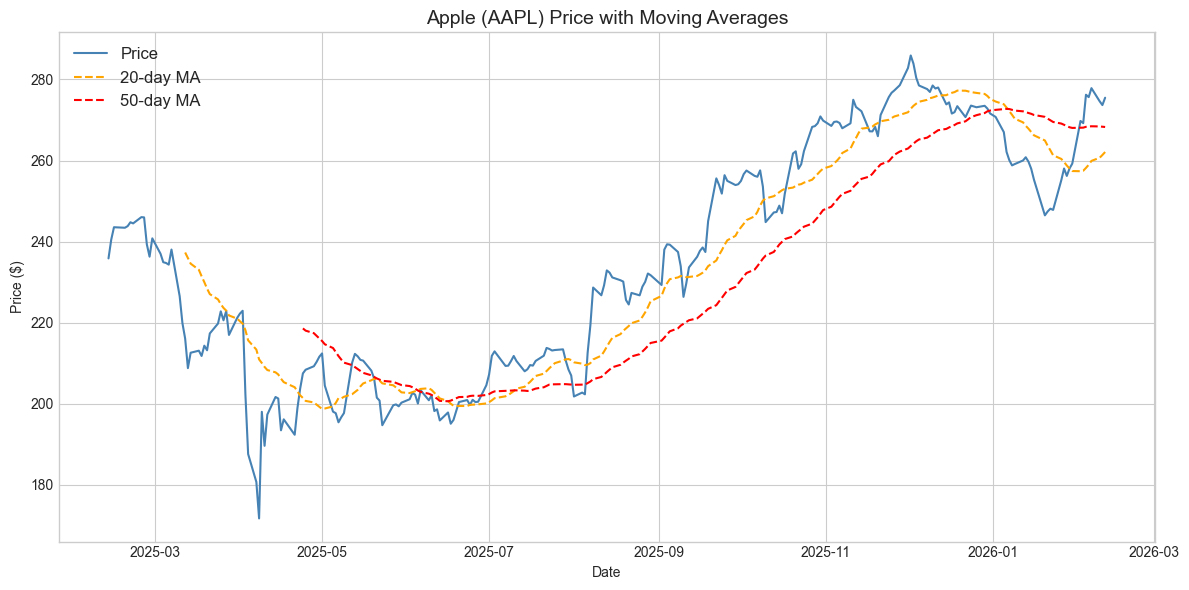

In [14]:
# Plot price with moving averages
plt.figure(figsize=(12, 6))
plt.plot(apple.index, apple['Close'], label='Price', color='steelblue', linewidth=1.5)
plt.plot(apple.index, apple['MA20'], label='20-day MA', color='orange', linewidth=1.5, linestyle='--')
plt.plot(apple.index, apple['MA50'], label='50-day MA', color='red', linewidth=1.5, linestyle='--')
plt.title('Apple (AAPL) Price with Moving Averages', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

**Observations:**
- The moving averages are **smoother** than the raw price
- The 50-day MA is **smoother** than the 20-day MA (longer window = more smoothing)
- The MAs **lag** behind the price (they're based on past data)
- When the price crosses above/below a MA, traders see that as a signal

This is a simple example of a **trading signal**. In later weeks, we'll see how AI can find much more complex patterns.

### Interactive Price Chart with Moving Averages

Let's build an interactive version with Plotly so you can zoom and hover.

In [15]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=apple.index, y=apple['Close'], name='Price',
                         line=dict(color='steelblue', width=1.5)))
fig.add_trace(go.Scatter(x=apple.index, y=apple['MA20'], name='20-day MA',
                         line=dict(color='orange', width=1.5, dash='dash')))
fig.add_trace(go.Scatter(x=apple.index, y=apple['MA50'], name='50-day MA',
                         line=dict(color='red', width=1.5, dash='dash')))

fig.update_layout(
    title='Apple (AAPL) Price with Moving Averages',
    yaxis_title='Price ($)',
    xaxis_title='Date',
    template='plotly_white',
    height=500,
    hovermode='x unified'
)

fig.show()

---

## Part 5: The Sharpe Ratio

How do we compare investments with different risk levels? The **Sharpe Ratio** answers: *"How much extra return do I get per unit of risk?"*

$$\text{Sharpe Ratio} = \frac{\text{Return} - \text{Risk-Free Rate}}{\text{Volatility}}$$

| Sharpe | Interpretation |
|--------|----------------|
| < 0.5 | Poor |
| 0.5 -- 1.0 | Acceptable |
| 1.0 -- 2.0 | Good |
| > 2.0 | Excellent (or suspicious!) |

In [16]:
# Calculate the Sharpe Ratio for Apple
# We'll assume a risk-free rate of ~5% (approximate current T-bill rate)
risk_free_rate = 0.05

sharpe = (annual_return - risk_free_rate) / annual_volatility

print(f"Annualized return:     {annual_return*100:.2f}%")
print(f"Risk-free rate:        {risk_free_rate*100:.2f}%")
print(f"Annualized volatility: {annual_volatility*100:.2f}%")
print(f"\nSharpe Ratio: {sharpe:.2f}")

if sharpe < 0.5:
    print("Interpretation: Poor risk-adjusted performance")
elif sharpe < 1.0:
    print("Interpretation: Acceptable risk-adjusted performance")
elif sharpe < 2.0:
    print("Interpretation: Good risk-adjusted performance")
else:
    print("Interpretation: Excellent risk-adjusted performance")

Annualized return:     20.64%
Risk-free rate:        5.00%
Annualized volatility: 31.80%

Sharpe Ratio: 0.49
Interpretation: Poor risk-adjusted performance


---

## Part 6: Comparing Two Stocks

Let's compare Apple with Microsoft to see how two tech stocks stack up.

In [17]:
# Download both stocks
tickers = ['AAPL', 'MSFT']
data = yf.download(tickers, period='1y')

# Extract closing prices (multi-ticker download keeps MultiIndex)
prices = data['Close']
prices.head()

[*********************100%***********************]  2 of 2 completed


Ticker,AAPL,MSFT
Date,,
2025-02-12,235.842102,406.044678
2025-02-13,240.481873,407.533722
2025-02-14,243.538574,405.439148
2025-02-18,243.409119,406.640289
2025-02-19,243.807358,411.732758


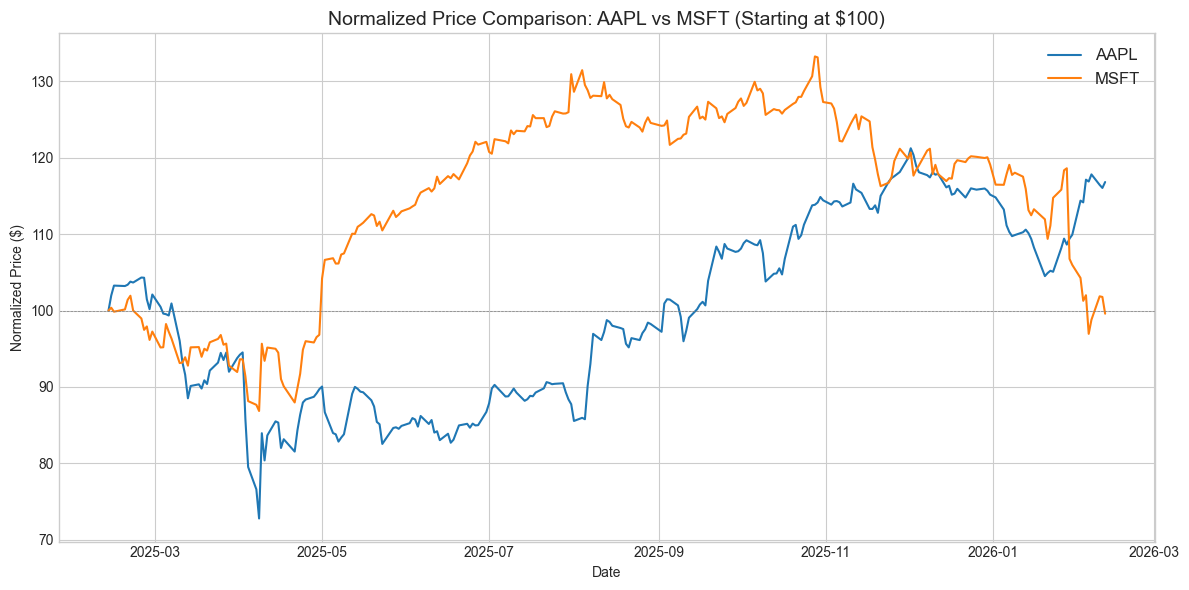

In [18]:
# Normalize prices to start at $100 for easy comparison
# This shows cumulative performance on the same scale
normalized = (prices / prices.iloc[0]) * 100

plt.figure(figsize=(12, 6))
for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], linewidth=1.5, label=col)

plt.axhline(y=100, color='gray', linewidth=0.5, linestyle='--')
plt.title('Normalized Price Comparison: AAPL vs MSFT (Starting at $100)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Normalized Price ($)')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
# Calculate returns for both
returns = prices.pct_change().dropna()

# Summary comparison table
summary = pd.DataFrame({
    'Avg Daily Return': returns.mean(),
    'Daily Std Dev': returns.std(),
    'Ann. Return': returns.mean() * 252,
    'Ann. Volatility': returns.std() * np.sqrt(252),
    'Sharpe Ratio': (returns.mean() * 252 - risk_free_rate) / (returns.std() * np.sqrt(252)),
    'Total Return': (prices.iloc[-1] / prices.iloc[0]) - 1
})

# Format nicely
summary_display = summary.copy()
for col in summary_display.columns:
    if col == 'Sharpe Ratio':
        summary_display[col] = summary_display[col].map('{:.2f}'.format)
    else:
        summary_display[col] = summary_display[col].map('{:.2%}'.format)

print("Stock Comparison: AAPL vs MSFT")
print("=" * 50)
summary_display.T

Stock Comparison: AAPL vs MSFT


Ticker,AAPL,MSFT
Avg Daily Return,0.08%,0.01%
Daily Std Dev,2.00%,1.67%
Ann. Return,20.64%,3.06%
Ann. Volatility,31.80%,26.44%
Sharpe Ratio,0.49,-0.07
Total Return,16.82%,-0.41%


In [20]:
# Correlation between the two stocks
correlation = returns['AAPL'].corr(returns['MSFT'])
print(f"Correlation between AAPL and MSFT daily returns: {correlation:.3f}")
print(f"\nInterpretation: A correlation of {correlation:.2f} means the stocks tend to")
if correlation > 0.7:
    print("move strongly together (highly correlated).")
elif correlation > 0.4:
    print("move somewhat together (moderately correlated).")
else:
    print("move somewhat independently (low correlation).")

Correlation between AAPL and MSFT daily returns: 0.410

Interpretation: A correlation of 0.41 means the stocks tend to
move somewhat together (moderately correlated).


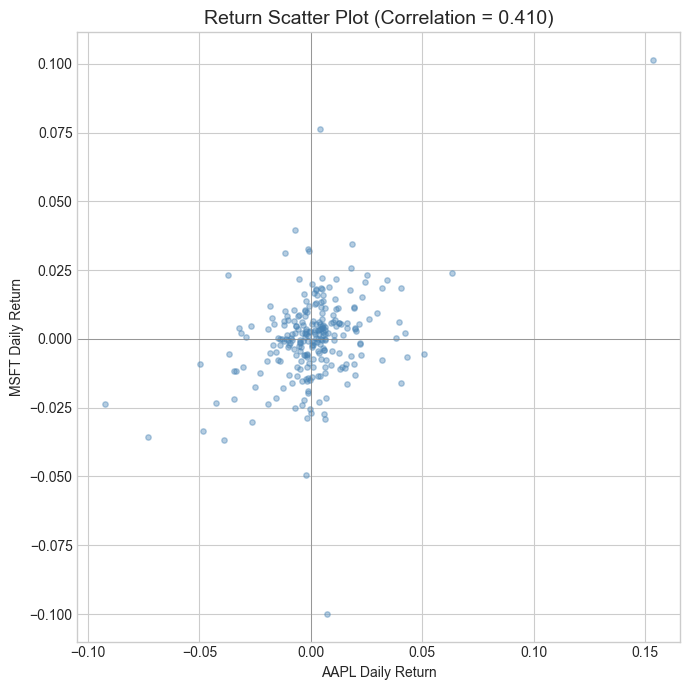

In [21]:
# Scatter plot of returns
plt.figure(figsize=(7, 7))
plt.scatter(returns['AAPL'], returns['MSFT'], alpha=0.4, s=15, color='steelblue')
plt.axhline(y=0, color='gray', linewidth=0.5)
plt.axvline(x=0, color='gray', linewidth=0.5)
plt.xlabel('AAPL Daily Return')
plt.ylabel('MSFT Daily Return')
plt.title(f'Return Scatter Plot (Correlation = {correlation:.3f})', fontsize=14)
plt.tight_layout()
plt.show()

---

## Part 7: Your Turn -- Exercises

Now it's your turn to apply what you've learned.

### Exercise 1: Analyze a Stock of Your Choice

Pick a stock you're interested in. Download its data, calculate returns, compute moving averages, and calculate the Sharpe Ratio.

Some ticker ideas: `TSLA`, `NVDA`, `AMZN`, `GOOG`, `JPM`, `GS`, `XOM`, `META`

[*********************100%***********************]  1 of 1 completed


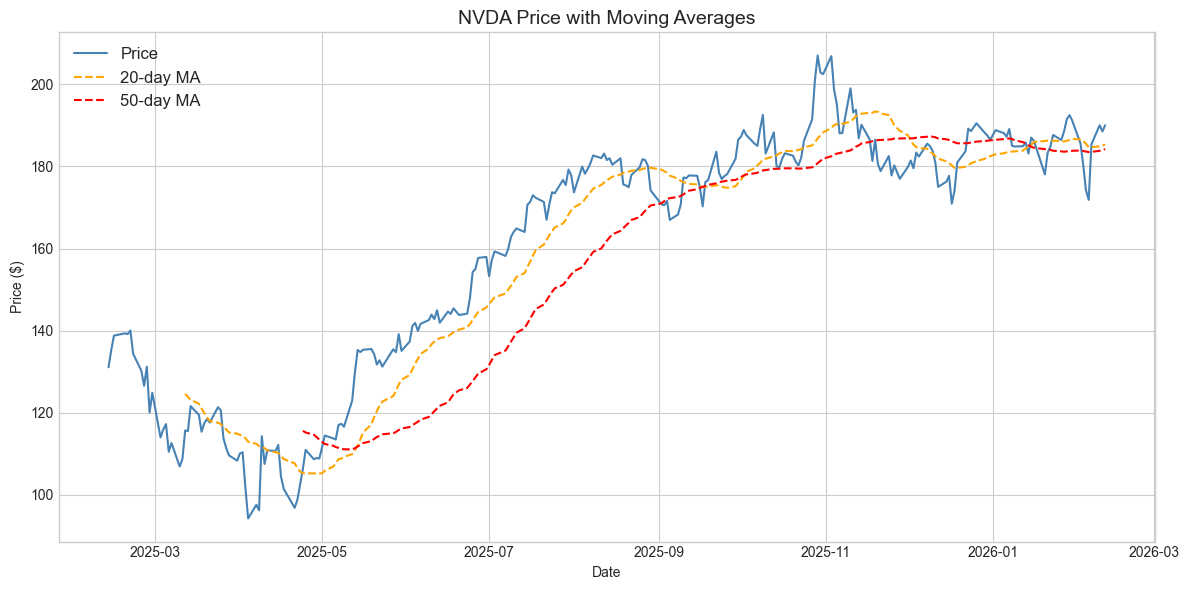

NVDA Sharpe Ratio: 0.95


In [22]:
# Exercise 1 solution
ticker = "NVDA"  # Change this to any ticker you want

# 1. Download data for a ticker of your choice
stock = yf.download(ticker, period="1y")

# 2. Flatten the MultiIndex columns (if present)
if isinstance(stock.columns, pd.MultiIndex):
    stock.columns = stock.columns.get_level_values(0)

# 3. Calculate daily returns
stock["Return"] = stock["Close"].pct_change()

# 4. Calculate 20-day and 50-day moving averages
stock["MA20"] = stock["Close"].rolling(window=20).mean()
stock["MA50"] = stock["Close"].rolling(window=50).mean()

# 5. Plot the price with moving averages
plt.figure(figsize=(12, 6))
plt.plot(stock.index, stock["Close"], label="Price", color="steelblue", linewidth=1.5)
plt.plot(stock.index, stock["MA20"], label="20-day MA", color="orange", linewidth=1.5, linestyle="--")
plt.plot(stock.index, stock["MA50"], label="50-day MA", color="red", linewidth=1.5, linestyle="--")
plt.title(f"{ticker} Price with Moving Averages", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 6. Calculate and print the Sharpe Ratio
avg_daily = stock["Return"].mean()
daily_vol = stock["Return"].std()
ann_return = avg_daily * 252
ann_vol = daily_vol * np.sqrt(252)
risk_free_rate = 0.05
sharpe_ratio = (ann_return - risk_free_rate) / ann_vol

print(f"{ticker} Sharpe Ratio: {sharpe_ratio:.2f}")

### Exercise 2: When Do Moving Averages Cross?

A popular trading signal is the **"Golden Cross"** -- when the short-term MA crosses *above* the long-term MA (bullish signal). The opposite is a **"Death Cross"** (bearish).

Using the Apple data from earlier, find the dates where the 20-day MA crossed the 50-day MA.

In [23]:
# Exercise 2 solution
# Ensure moving averages exist (run earlier MA cell if not)
apple["Signal"] = apple["MA20"] - apple["MA50"]

# Identify crossover dates (sign change in Signal)
crossovers = apple[apple["Signal"] * apple["Signal"].shift(1) < 0].copy()

# Label the crossover type
crossovers["Crossover"] = np.where(crossovers["Signal"] > 0, "Golden Cross", "Death Cross")

# Show the dates and types
crossovers[["Crossover"]]

Price,Crossover
Date,
2025-06-05,Golden Cross
2025-06-17,Death Cross
2025-07-11,Golden Cross
2026-01-07,Death Cross


---

## Part 8: Prompt Engineering for Finance

Now that you've worked with financial data hands-on, let's practice using AI to help with analysis.

**Prompt engineering** = writing better instructions to get better AI outputs.

### Principles:
1. **Be specific**: Instead of "analyze this," say "calculate the Sharpe ratio"
2. **Provide context**: "I'm a beginner" vs. "I'm preparing a board presentation"
3. **Give examples**: Show the AI what format you want
4. **Include data**: Paste actual numbers from your analysis
5. **Iterate**: If the first response isn't right, refine your prompt

### Exercise 3: Explain a Concept

**Task:** Write a prompt asking an AI (ChatGPT or Claude) to explain what a moving average crossover means and why traders care about it.

**Bad prompt:** "What is a moving average?"

**Write a better prompt below, test it, and paste the response:**

```
YOUR PROMPT HERE:
I would like for you to go into a in depth explanation of what moving average is? From then add what the crossover aspect adds to it. Explain why traders see the high value into this method compared to other similar methods


```

**AI Response:** (Paste response here)

```

Moving Averages: An In-Depth Explanation
What is a Moving Average?
A moving average is a statistical calculation that smooths out price data by creating a constantly updated average price over a specific time period. It's called "moving" because as new data becomes available, the oldest data point is dropped and the newest is added, causing the average to shift or "move" forward in time.
The core concept: Rather than looking at raw, volatile price movements, a moving average helps traders identify the underlying trend by filtering out short-term price fluctuations or "noise." Think of it like looking at a coastline from an airplane versus standing on the beach—from higher up, you see the general shape without being distracted by every wave and ripple.
How it's calculated: For a simple moving average (SMA), you add up the closing prices for a specified number of periods and divide by that number. For example, a 10-day SMA adds the last 10 closing prices and divides by 10. Tomorrow, you drop the oldest price, add the newest, and recalculate.
There are several types of moving averages, with the two most common being:

Simple Moving Average (SMA): Gives equal weight to all prices in the period
Exponential Moving Average (EMA): Gives more weight to recent prices, making it more responsive to new information

Moving averages serve multiple purposes: they identify trend direction (if price is above the MA, the trend is generally up; below it, generally down), provide dynamic support and resistance levels, and help smooth erratic price movements to reveal the bigger picture.
The Moving Average Crossover Strategy
The crossover method adds a powerful dimension to moving average analysis by using two moving averages of different periods simultaneously—typically a shorter-term MA and a longer-term MA. The strategy generates trading signals when these two lines cross each other.
How crossovers work: When the faster (shorter-period) moving average crosses above the slower (longer-period) moving average, it's called a "golden cross" or bullish crossover, signaling potential upward momentum. Conversely, when the faster MA crosses below the slower MA, it's a "death cross" or bearish crossover, suggesting potential downward momentum.
Common combinations include the 50-day and 200-day MAs for longer-term trading, or the 9-day and 21-day MAs for shorter-term trading. The logic is elegant: when short-term price action (represented by the fast MA) begins outpacing the longer-term trend (the slow MA), it suggests a change in market sentiment and momentum.
What crossovers add to the basic MA: While a single moving average tells you about trend direction, crossovers provide specific entry and exit signals with clearer timing. They also offer confirmation—a crossover represents two different timeframes agreeing on direction, which can filter out false signals that a single MA might generate. Additionally, crossovers help identify momentum shifts earlier than waiting for price to break through a single MA level.
Why Traders Value Crossovers Over Similar Methods
The moving average crossover strategy has endured for decades because it offers several advantages over other technical methods:
Objective and unemotional: Unlike subjective pattern recognition or complex indicators requiring interpretation, a crossover is binary—it either happens or it doesn't. This removes emotional decision-making from trading, which is often a trader's biggest enemy. You don't need to guess whether a pattern is "complete enough" or whether an indicator reading is "too extreme"—the math gives you a clear signal.
Trend-following DNA: Markets tend to trend more than they mean-revert over certain timeframes, and crossover strategies are designed to capture these trends. Unlike oscillators (like RSI or Stochastic) that work best in ranging markets and can give premature signals in strong trends, moving average crossovers keep you aligned with the dominant direction. When a market is truly trending, crossovers can capture substantial moves without getting shaken out by minor corrections.
Built-in risk management: The crossover system inherently provides both entry and exit signals. When a bullish crossover occurs, you know to enter long. When it reverses, you know to exit. This creates a complete trading system rather than just an indicator that tells you "overbought" or "oversold" without clear action steps. The slower MA also often acts as a trailing stop, protecting profits as trends develop.
Simplicity and universality: The strategy works across different markets (stocks, forex, commodities, crypto) and timeframes (from minutes to months). This universality means traders can apply the same logical framework whether they're day trading or investing for retirement. Compared to complex indicators with multiple parameters, moving averages require minimal decisions—just choose your two periods.
Reduced whipsaw compared to price crossovers: When traders use price crossing a single moving average as a signal, they often get whipsawed (stopped out repeatedly) in choppy, sideways markets. Using two MAs instead creates a buffer—both averages need to agree on direction before a signal triggers, which tends to filter out some of the noise inherent in using just price and one MA.
Historical validation: Crossover strategies have been backtested extensively across decades of market data. While not perfect (no strategy is), they've demonstrated the ability to capture major trends and avoid catastrophic losses during trend reversals. The 50/200-day crossover, in particular, has a track record of identifying significant market regime changes.
That said, crossovers aren't without weaknesses. They lag price action by design, meaning you'll never catch the absolute top or bottom. They also perform poorly in sideways, consolidating markets where frequent crossovers can lead to multiple small losses. Many professional traders use crossovers as part of a broader system, combining them with volume analysis, support/resistance levels, or fundamental factors to improve accuracy.
The enduring appeal comes down to this: moving average crossovers offer a systematic, reproducible way to identify and follow trends with clear rules for entry and exit, making them accessible to beginners while remaining robust enough for professional use. In a field where complexity often masks poor performance, their straightforward logic and historical effectiveness continue to make them a cornerstone of technical analysis.

```

**Your evaluation:** Was the response helpful? What made your prompt effective (or not)?

In [ ]:
# What made my prompt effective was the clear identifying what the basic of moving average was and expalnding on it. It did not throw me 
#immediately into code, but rather explained the concept and then asked for a specific implementation. This made it easier to understand what was being asked and how to approach it.
#I also for comparisons to give me an actual reason why we are using this methods compared to other ones.

### Exercise 4: Interpret Your Results

**Task:** Take the summary statistics you calculated above for Apple (or your chosen stock) and write a prompt asking the AI to interpret them.

**Tips:**
- Include the actual numbers in your prompt
- Ask for a comparison to the S&P 500 (historically ~10%/year return, ~15% volatility)
- Specify your audience (e.g., "explain to someone with no finance background")

```
YOUR PROMPT HERE:
analyze this data and create a comparison to the S&P 500 (historically ~10%/year return, ~15% volatility) then simplify so that anyone can understand. Specifically i want some basic visuals that will assist as well:
Apple (AAPL) -- Summary Statistics ==================================================  Daily:   Average daily return:  0.0008 (0.08%)   Daily std deviation:   0.0200 (2.00%)   Best day:              0.1533 (15.33%)   Worst day:             -0.0925 (-9.25%)  Annualized:   Annualized return:     0.2064 (20.64%)   Annualized volatility: 0.3180 (31.80%)  Total return over period: 16.82%   $1,000 invested became: $1,168.15

```

In [ ]:
#It had also created visualization but cannot paste

**AI Response:** (Paste response here)
```
The Key Finding:
Apple delivered double the returns (20.64% vs 10%) but with double the risk (31.80% volatility vs 15%) compared to the S&P 500.
What This Means in Plain English:
Your Investment Results:

You put in $1,000 and got back $1,168.15 (16.82% gain)
With the S&P 500, you'd have about $1,100

The Roller Coaster Factor:

Apple's best day: Up 15.33% (imagine gaining $153 on $1,000 in ONE day!)
Apple's worst day: Down 9.25% (losing $92 in ONE day)
The S&P 500 is much calmer with typical swings around 5-7%

The Trade-off:
You got more reward with Apple, but had to stomach much bigger swings. Some days your investment jumped up by huge amounts, other days it dropped scary fast. The S&P 500 is like the "slow and steady" approach—less exciting but also less nerve-wracking.

```

---

## Part 9: Reflection

Answer these questions based on your experience today:

### 1. What did you learn about working with financial data in Python?

*Your answer:*
I learned that there is a lot more depth analysis we can take advantage of when working with financial data in Python

### 2. Which chart type (line, candlestick, histogram) did you find most informative and why?

*Your answer:*
I did like the candlestick more informative since it showed us the visualizations and the comparisons

### 3. What are the limitations of using AI for financial analysis?

*Your answer:*
Some limitations will be when there are random events that are unexpected. An example is COVID happened later, then how would the AI respond to that? It has no historical data and would error out and might cause some sort of poor choice. Another example is if there is an outside event that may impact stock that it may not adjust to